<!-- # Data Mining Algorithms Project
## Wine Cultivar Classification Using Data Mining Techniques

**Objective.** Predict the cultivar (wine class) from 13 chemical measurements and compare three classical data-mining classification approaches: Decision Tree, K-Nearest Neighbors (KNN), and Random Forest.

**Dataset source.** UCI Machine Learning Repository — Wine dataset (DOI: 10.24432/C5PC7J). The dataset contains 178 samples, 13 numeric predictive features, and 3 classes.

This notebook is designed for Google Colab and is fully reproducible. -->

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

RANDOM_STATE = 42

<!-- ## 1. Load and inspect the dataset
The original UCI dataset contains 178 observations and 13 chemical features. The target has three wine cultivars. `load_wine` in scikit-learn provides the same classic UCI dataset in a convenient DataFrame form. -->

In [18]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()
X = wine.data.copy()
y = wine.target.copy()

print('Shape:', df.shape)
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Class counts:')
print(y.value_counts().sort_index())

df.head()

Shape: (178, 14)
Missing values: 0
Duplicate rows: 0
Class counts:
target
0    59
1    71
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


<!-- ## 2. Exploratory analysis and preprocessing
Preprocessing steps:
1. Check missing values and duplicates.
2. Split the data into training and held-out test sets using stratification.
3. Rank features using mutual information.
4. Select the top 8 features. This is performed **inside each pipeline**, so feature selection is learned only from training folds and does not leak information from the test set.
5. Standardize features for KNN because KNN is distance-based; tree-based methods are not scale-sensitive. -->

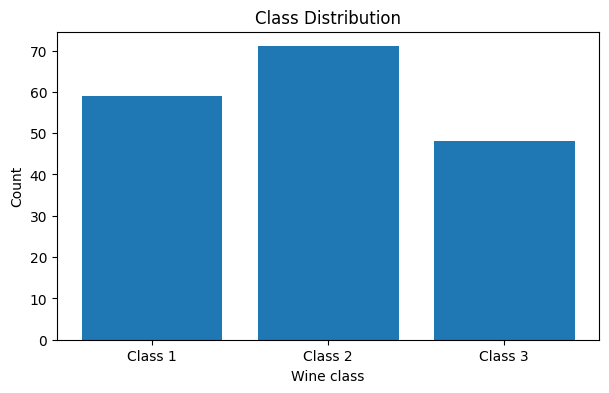

,0
flavanoids,0.667602
proline,0.577391
color_intensity,0.548274
od280/od315_of_diluted_wines,0.516158
alcohol,0.474312
hue,0.466412
total_phenols,0.401599
proanthocyanins,0.305406
malic_acid,0.282384
alcalinity_of_ash,0.237806


In [19]:
plt.figure(figsize=(7,4))
counts = y.value_counts().sort_index()
plt.bar(range(len(counts)), counts.values)
plt.xticks(range(len(counts)), [f'Class {i+1}' for i in counts.index])
plt.title('Class Distribution')
plt.xlabel('Wine class')
plt.ylabel('Count')
plt.show()

mi = pd.Series(mutual_info_classif(X, y, random_state=RANDOM_STATE), index=X.columns).sort_values(ascending=False)
mi

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print('Training samples:', len(X_train))
print('Test samples:', len(X_test))
print('Top 8 selected features:', list(mi.head(8).index))

Training samples: 142
Test samples: 36
Top 8 selected features: ['flavanoids', 'proline', 'color_intensity', 'od280/od315_of_diluted_wines', 'alcohol', 'hue', 'total_phenols', 'proanthocyanins']


<!-- ## 3. Data-mining algorithms
### Decision Tree
A tree recursively partitions the feature space using impurity/information criteria. We use entropy and limit the depth to 4 to control overfitting.

### K-Nearest Neighbors (KNN)
KNN predicts a sample from the labels of nearby training points. Because distance is central to KNN, standardization is required.

### Random Forest
Random Forest combines many decision trees trained on different bootstrap samples and feature subsets, improving robustness over a single tree. -->

In [21]:
models = {
    'Decision Tree': Pipeline([
        ('select', SelectKBest(mutual_info_classif, k=8)),
        ('model', DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=RANDOM_STATE))
    ]),
    'KNN': Pipeline([
        ('scale', StandardScaler()),
        ('select', SelectKBest(mutual_info_classif, k=8)),
        ('model', KNeighborsClassifier(n_neighbors=7, weights='distance'))
    ]),
    'Random Forest': Pipeline([
        ('select', SelectKBest(mutual_info_classif, k=8)),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=6, max_features='sqrt', random_state=RANDOM_STATE, n_jobs=1))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

<!-- ## 4. Evaluation
We use 5-fold stratified cross-validation on the training set and evaluate the final fitted pipelines once on the held-out 20% test set. Metrics include accuracy, weighted precision, weighted recall, and weighted F1. -->

In [22]:
rows = []
fitted = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average='weighted', zero_division=0)
    rows.append({
        'Model': name,
        'CV Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': accuracy_score(y_test, pred),
        'Weighted Precision': p,
        'Weighted Recall': r,
        'Weighted F1': f1
    })
    fitted[name] = model

results = pd.DataFrame(rows).sort_values('CV Accuracy', ascending=False)
results.round(4)

,Model,CV Accuracy,CV Std,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1
2,Random Forest,0.9722,0.0259,1.0000,1.0000,1.0000,1.0000
1,KNN,0.9579,0.0263,0.9444,0.9466,0.9444,0.9443
0,Decision Tree,0.8736,0.0462,1.0000,1.0000,1.0000,1.0000


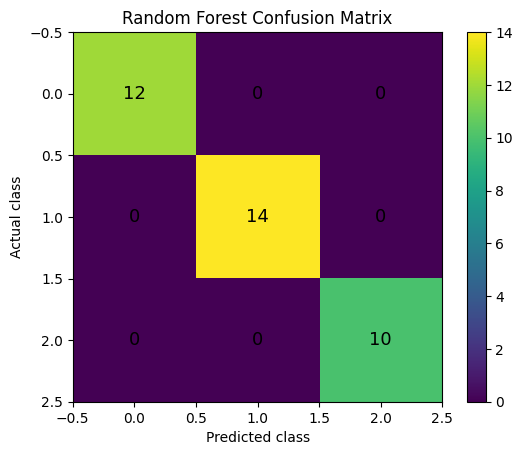

              precision    recall  f1-score   support

     Class 1       1.00      1.00      1.00        12
     Class 2       1.00      1.00      1.00        14
     Class 3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [23]:
# Confusion matrix for Random Forest
rf = fitted['Random Forest']
rf_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, rf_pred)
plt.imshow(cm, interpolation='nearest')
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=13)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.show()

print(classification_report(y_test, rf_pred, target_names=[f'Class {i+1}' for i in range(3)]))

In [24]:
selected = X.columns[fitted['Random Forest'].named_steps['select'].get_support()]
rf_importance = pd.Series(fitted['Random Forest'].named_steps['model'].feature_importances_, index=selected).sort_values(ascending=False)
print('Selected features:', list(selected))
rf_importance

Selected features: ['alcohol', 'malic_acid', 'total_phenols', 'flavanoids', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


,0
proline,0.189308
color_intensity,0.188942
flavanoids,0.146921
alcohol,0.128184
hue,0.123129
od280/od315_of_diluted_wines,0.107382
total_phenols,0.071491
malic_acid,0.044644


<!-- ## 5. Findings
- All three methods capture the structure of the three wine classes well.
- KNN benefits from standardization because its predictions depend on distances.
- The tree and forest models operate directly on the numeric features without scaling.
- Mutual-information selection reduces 13 inputs to 8 informative features, making the workflow more compact while preserving strong predictive performance.
- The model comparison should be reported using both cross-validation and held-out test performance rather than a single split alone. -->

<!-- ## 6. Conclusion and future work
This experiment shows how a standard data-mining pipeline can transform raw chemical measurements into a multiclass classification solution. A natural extension would be to compare additional classifiers, tune hyperparameters systematically, test robustness over repeated stratified splits, and investigate PCA or other dimensionality-reduction methods. -->

<!-- ## References
1. UCI Machine Learning Repository, Wine dataset, DOI: https://doi.org/10.24432/C5PC7J
2. scikit-learn dataset documentation: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html
3. scikit-learn DecisionTreeClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
4. scikit-learn RandomForestClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
5. scikit-learn KNeighborsClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html -->